# Step 6 — User-Guided Gating Mechanism

### Where we are in the pipeline
```
prototype_learning.ipynb
        |
        v
interactions_prototype.jsonl
        |
        v
gating.ipynb   <-- YOU ARE HERE
        |
        v
interactions_gated.jsonl
user_embeddings.json
```

### What this notebook does

This notebook implements **Step 6** of the paper exactly:

**User Embedding**  
Each user gets a learnable vector `u ∈ R^d_u`, initialised randomly,  
that gets updated during training to encode that user's modality preference.

**Gating Mechanism**  
`g = σ( Wg [z_v ; z_t ; u] )`  
The gate `g ∈ (0,1)^d` is a per-dimension blend weight.  
Values near 1 → trust the visual embedding more.  
Values near 0 → trust the text embedding more.

**Unified Representation**  
`Z_ui = g ⊙ z_v + (1 - g) ⊙ z_t`

**Rating Prediction**  
`ŷ_ui = W_r^T Z_ui + b_r`

### What gets learned
- `user_embedding_table` — one 64-dim vector per user, shaped by rating supervision
- `Wg` — the gate projection matrix
- `W_r, b_r` — the final rating prediction head

### Output
- `interactions_gated.jsonl` — records augmented with `Z_ui` and gate values `g`
- `user_embeddings.json` — final trained embedding vector for every user

## Cell 1 — Install dependencies

In [1]:
!pip install torch numpy tqdm matplotlib scikit-learn

## Cell 2 — Imports

In [2]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from collections import defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

print("Imports OK")

Imports OK


## Cell 3 — Configuration

In [3]:
# ── I/O ───────────────────────────────────────────────────────────────────────
INPUT_PATH          = "interactions_prototype.jsonl"  # output of prototype_learning.ipynb
OUTPUT_PATH         = "interactions_gated.jsonl"      # records + Z_ui + gate g
USER_EMBEDDINGS_OUT = "user_embeddings.json"          # final trained user vectors

# ── Dimensions ────────────────────────────────────────────────────────────────
# EMB_DIM must match whatever K your prototype notebook settled on.
# z_v and z_t from interactions_prototype.jsonl are 768-dim.
EMB_DIM      = 768    # dimension of z_v and z_t (from prototype step)
USER_DIM     = 64     # dimension of the learnable user embedding

# The gate input is [z_v ; z_t ; u] concatenated, so its size is:
# EMB_DIM + EMB_DIM + USER_DIM = 768 + 768 + 64 = 1600
# The gate output matches EMB_DIM so it can blend z_v and z_t dimension-wise.
GATE_INPUT_DIM = EMB_DIM + EMB_DIM + USER_DIM   # 1600

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS        = 50
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Input            : {INPUT_PATH}")
print(f"Output           : {OUTPUT_PATH}")
print(f"User emb output  : {USER_EMBEDDINGS_OUT}")
print(f"EMB_DIM          : {EMB_DIM}")
print(f"USER_DIM         : {USER_DIM}")
print(f"GATE_INPUT_DIM   : {GATE_INPUT_DIM}")
print(f"Epochs           : {EPOCHS}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Learning rate    : {LEARNING_RATE}")
print(f"Device           : {DEVICE}")

Input            : interactions_prototype.jsonl
Output           : interactions_gated.jsonl
User emb output  : user_embeddings.json
EMB_DIM          : 768
USER_DIM         : 64
GATE_INPUT_DIM   : 1600
Epochs           : 50
Batch size       : 32
Learning rate    : 0.001
Device           : cuda


## Cell 4 — Build User Index

We scan the entire file once to collect every unique `user_id` and assign  
each an integer index. This index is what the embedding table uses as a  
row lookup — the network never sees the raw string ID.

In [4]:
# ── First pass: collect all unique user IDs ────────────────────────────────────
unique_users = set()
with open(INPUT_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            rec = json.loads(line)
            unique_users.add(rec["user_id"])

# Sort for deterministic ordering — same index every run
unique_users = sorted(unique_users)
user2idx     = {uid: idx for idx, uid in enumerate(unique_users)}
num_users    = len(unique_users)

print(f"Unique users found : {num_users:,}")
print(f"Example mapping    : '{unique_users[0]}' → index 0")
print()
print("This mapping is saved alongside the embeddings so you can always")
print("look up a user_id string → their trained vector.")

Unique users found : 37
Example mapping    : 'AEEO4SJ4MMZH2GD3NY56GLGO3VEA' → index 0

This mapping is saved alongside the embeddings so you can always
look up a user_id string → their trained vector.


## Cell 5 — Dataset

Reads `interactions_prototype.jsonl` and returns tensors per interaction.  
`z_v` and `z_t` come directly from the prototype step — no re-computation needed.  
The dataset also returns the integer user index for embedding table lookup.

In [5]:
class GatingDataset(Dataset):
    """
    Reads interactions_prototype.jsonl.
    Each item returns:
        z_v      : (EMB_DIM,) sentiment-aware visual embedding from prototype step
        z_t      : (EMB_DIM,) sentiment-aware text embedding from prototype step
        rating   : scalar in [0, 1]  — normalised from [1, 5]
        user_idx : int — integer index into the embedding table
        user_id  : str — original user ID string
        asin     : str
        raw_rating: float — original 1–5 star rating
    """

    def __init__(self, path: str, user2idx: dict):
        self.records = []
        skipped = 0

        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)

                zv = rec.get("z_v")
                zt = rec.get("z_t")
                r  = rec.get("rating")
                uid = rec.get("user_id")

                if zv is None or zt is None or r is None or uid is None:
                    skipped += 1
                    continue
                if len(zv) != EMB_DIM or len(zt) != EMB_DIM:
                    skipped += 1
                    continue
                if uid not in user2idx:
                    skipped += 1
                    continue

                self.records.append({
                    "z_v"       : torch.tensor(zv, dtype=torch.float32),
                    "z_t"       : torch.tensor(zt, dtype=torch.float32),
                    # Normalise rating to [0, 1]
                    "rating"    : torch.tensor((float(r) - 1.0) / 4.0, dtype=torch.float32),
                    "user_idx"  : torch.tensor(user2idx[uid], dtype=torch.long),
                    "user_id"   : uid,
                    "asin"      : rec.get("asin", ""),
                    "raw_rating": float(r),
                })

        print(f"Loaded  : {len(self.records):,} interactions")
        if skipped:
            print(f"Skipped : {skipped} records (missing fields / unknown users)")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]


def collate_fn(batch):
    return {
        "z_v"       : torch.stack([b["z_v"]        for b in batch]),
        "z_t"       : torch.stack([b["z_t"]        for b in batch]),
        "rating"    : torch.stack([b["rating"]     for b in batch]),
        "user_idx"  : torch.stack([b["user_idx"]   for b in batch]),
        "user_id"   : [b["user_id"]   for b in batch],
        "asin"      : [b["asin"]      for b in batch],
        "raw_rating": [b["raw_rating"] for b in batch],
    }


dataset    = GatingDataset(INPUT_PATH, user2idx)
dataloader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    collate_fn  = collate_fn,
)
print(f"Batches per epoch : {len(dataloader)}")

Loaded  : 166 interactions
Batches per epoch : 6


## Cell 6 — User-Guided Gating Model

This is the core module. Three learnable components:

**1. `user_embedding` (nn.Embedding)**  
A lookup table of shape `(num_users, USER_DIM)`.  
Initialised with Xavier uniform — better conditioning than default random.  
Each row is one user's embedding. Gets updated via backprop.

**2. `gate_network` (Linear)**  
Takes `[z_v ; z_t ; u]` concatenated → outputs `EMB_DIM` values → sigmoid → gate `g`.  
This is exactly the paper's `g = σ(Wg [z_v ; z_t ; u])`.

**3. `rating_head` (Linear)**  
Takes the unified representation `Z_ui` → predicts a scalar rating.  
This replaces the simple average fusion from the prototype notebook.

In [6]:
class UserGuidedGatingModel(nn.Module):
    """
    Implements Step 6 of the multimodal recommendation paper.

    Parameters
    ----------
    num_users   : int  — total unique users in the dataset
    user_dim    : int  — dimension of user embedding (USER_DIM, default 64)
    emb_dim     : int  — dimension of z_v and z_t (EMB_DIM, default 768)
    """

    def __init__(self, num_users: int, user_dim: int, emb_dim: int):
        super().__init__()

        self.emb_dim  = emb_dim
        self.user_dim = user_dim

        # ── Learnable user embedding table ────────────────────────────────────
        # Shape: (num_users, user_dim)
        # Each row = one user's embedding, randomly initialised, learned via backprop.
        self.user_embedding = nn.Embedding(num_users, user_dim)
        nn.init.xavier_uniform_(self.user_embedding.weight)

        # ── Gate network ──────────────────────────────────────────────────────
        # Input:  [z_v ; z_t ; u]  →  size = emb_dim + emb_dim + user_dim
        # Output: emb_dim values passed through sigmoid → gate g ∈ (0,1)^emb_dim
        # This is g = σ(Wg [z_v ; z_t ; u]) from the paper.
        self.gate_network = nn.Linear(emb_dim + emb_dim + user_dim, emb_dim)

        # ── Rating prediction head ─────────────────────────────────────────────
        # Takes unified Z_ui → scalar rating in [0,1]
        # ŷ_ui = Wr^T Z_ui + br
        self.rating_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_v, z_t, user_idx):
        """
        Parameters
        ----------
        z_v      : (B, emb_dim)  — sentiment-aware visual embedding
        z_t      : (B, emb_dim)  — sentiment-aware text embedding
        user_idx : (B,)          — integer user indices for embedding lookup

        Returns
        -------
        y_hat  : (B,)         — predicted rating in [0, 1]
        Z_ui   : (B, emb_dim) — unified gated representation
        g      : (B, emb_dim) — gate values (how much visual vs text per dimension)
        u      : (B, user_dim)— user embedding (for saving after training)
        """

        # Step 1: look up user embedding
        # user_idx is a batch of integers e.g. [42, 17, 305]
        # This returns the corresponding rows from the embedding table
        u = self.user_embedding(user_idx)            # (B, user_dim)

        # Step 2: concatenate [z_v ; z_t ; u] along the feature dimension
        # z_v:  (B, 768)
        # z_t:  (B, 768)
        # u:    (B, 64)
        # cat → (B, 1600)
        gate_input = torch.cat([z_v, z_t, u], dim=-1)   # (B, 1600)

        # Step 3: compute gate — g = σ(Wg [z_v ; z_t ; u])
        g = torch.sigmoid(self.gate_network(gate_input)) # (B, 768)

        # Step 4: blend modalities
        # Dimensions where g≈1 → Z_ui takes from z_v (visual)
        # Dimensions where g≈0 → Z_ui takes from z_t (text)
        Z_ui = g * z_v + (1 - g) * z_t                  # (B, 768)

        # Step 5: predict rating from unified representation
        y_hat = self.rating_head(Z_ui).squeeze(1)        # (B,)

        return y_hat, Z_ui, g, u


# ── Smoke test before training ─────────────────────────────────────────────────
model = UserGuidedGatingModel(
    num_users = num_users,
    user_dim  = USER_DIM,
    emb_dim   = EMB_DIM,
).to(DEVICE)

dummy_zv  = torch.randn(4, EMB_DIM).to(DEVICE)
dummy_zt  = torch.randn(4, EMB_DIM).to(DEVICE)
dummy_idx = torch.randint(0, num_users, (4,)).to(DEVICE)

with torch.no_grad():
    y_hat, Z_ui, g, u = model(dummy_zv, dummy_zt, dummy_idx)

print("Model initialised successfully")
print(f"y_hat shape : {y_hat.shape}   — expected (4,)")
print(f"Z_ui shape  : {Z_ui.shape}   — expected (4, {EMB_DIM})")
print(f"g shape     : {g.shape}   — expected (4, {EMB_DIM})")
print(f"u shape     : {u.shape}    — expected (4, {USER_DIM})")
print(f"y_hat range : [{y_hat.min().item():.3f}, {y_hat.max().item():.3f}]  — expected in [0, 1]")
print(f"g range     : [{g.min().item():.3f}, {g.max().item():.3f}]  — expected in (0, 1)")
print()
print(f"Total trainable parameters:")
total_params = sum(p.numel() for p in model.parameters())
user_params  = model.user_embedding.weight.numel()
gate_params  = sum(p.numel() for p in model.gate_network.parameters())
head_params  = sum(p.numel() for p in model.rating_head.parameters())
print(f"  user_embedding : {user_params:,}  ({num_users} users × {USER_DIM} dims)")
print(f"  gate_network   : {gate_params:,}")
print(f"  rating_head    : {head_params:,}")
print(f"  TOTAL          : {total_params:,}")

Model initialised successfully
y_hat shape : torch.Size([4])   — expected (4,)
Z_ui shape  : torch.Size([4, 768])   — expected (4, 768)
g shape     : torch.Size([4, 768])   — expected (4, 768)
u shape     : torch.Size([4, 64])    — expected (4, 64)
y_hat range : [0.494, 0.504]  — expected in [0, 1]
g range     : [0.135, 0.895]  — expected in (0, 1)

Total trainable parameters:
  user_embedding : 2,368  (37 users × 64 dims)
  gate_network   : 1,229,568
  rating_head    : 49,281
  TOTAL          : 1,281,217


## Cell 7 — Training Loop

Single MSE loss on rating prediction.  
Every backward pass updates three things simultaneously:
- The user embedding rows that appeared in the batch
- The gate network weights
- The rating head weights

Users who appear in more interactions get more gradient updates and  
thus have better-trained embeddings by the end.

In [7]:
model     = UserGuidedGatingModel(
    num_users = num_users,
    user_dim  = USER_DIM,
    emb_dim   = EMB_DIM,
).to(DEVICE)

optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "mse_loss"  : [],
    "mean_gate" : [],   # average gate value — tells us if model is biased toward one modality
}

print(f"Starting training — {EPOCHS} epochs, {len(dataloader)} batches/epoch")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):

    model.train()
    epoch_mse       = 0.0
    epoch_gate_mean = 0.0
    n_batches       = 0

    for batch in dataloader:
        z_v      = batch["z_v"].to(DEVICE)        # (B, EMB_DIM)
        z_t      = batch["z_t"].to(DEVICE)        # (B, EMB_DIM)
        rating   = batch["rating"].to(DEVICE)     # (B,)
        user_idx = batch["user_idx"].to(DEVICE)   # (B,)  integer indices

        # Forward pass
        y_hat, Z_ui, g, u = model(z_v, z_t, user_idx)

        # MSE loss between predicted and actual normalised rating
        loss = F.mse_loss(y_hat, rating)

        # Backward pass
        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()

        epoch_mse       += loss.item()
        epoch_gate_mean += g.mean().item()   # track mean gate across batch
        n_batches       += 1

    avg_mse  = epoch_mse       / n_batches
    avg_gate = epoch_gate_mean / n_batches

    history["mse_loss"].append(avg_mse)
    history["mean_gate"].append(avg_gate)

    print(
        f"Epoch {epoch:3d}/{EPOCHS} | "
        f"MSE {avg_mse:.4f} | "
        f"Mean gate {avg_gate:.4f}  "
        f"({'visual-biased' if avg_gate > 0.5 else 'text-biased'})"
    )

print("=" * 60)
print("Training complete.")

Starting training — 50 epochs, 6 batches/epoch
Epoch   1/50 | MSE 0.1396 | Mean gate 0.4998  (text-biased)
Epoch   2/50 | MSE 0.1230 | Mean gate 0.4950  (text-biased)
Epoch   3/50 | MSE 0.1021 | Mean gate 0.4838  (text-biased)
Epoch   4/50 | MSE 0.0764 | Mean gate 0.4692  (text-biased)
Epoch   5/50 | MSE 0.0612 | Mean gate 0.4516  (text-biased)
Epoch   6/50 | MSE 0.0434 | Mean gate 0.4359  (text-biased)
Epoch   7/50 | MSE 0.0334 | Mean gate 0.4229  (text-biased)
Epoch   8/50 | MSE 0.0271 | Mean gate 0.4101  (text-biased)
Epoch   9/50 | MSE 0.0219 | Mean gate 0.3999  (text-biased)
Epoch  10/50 | MSE 0.0197 | Mean gate 0.3941  (text-biased)
Epoch  11/50 | MSE 0.0152 | Mean gate 0.3957  (text-biased)
Epoch  12/50 | MSE 0.0160 | Mean gate 0.3967  (text-biased)
Epoch  13/50 | MSE 0.0117 | Mean gate 0.3940  (text-biased)
Epoch  14/50 | MSE 0.0097 | Mean gate 0.4065  (text-biased)
Epoch  15/50 | MSE 0.0089 | Mean gate 0.4043  (text-biased)
Epoch  16/50 | MSE 0.0081 | Mean gate 0.4124  (text-b

## Cell 8 — Training Diagnostics

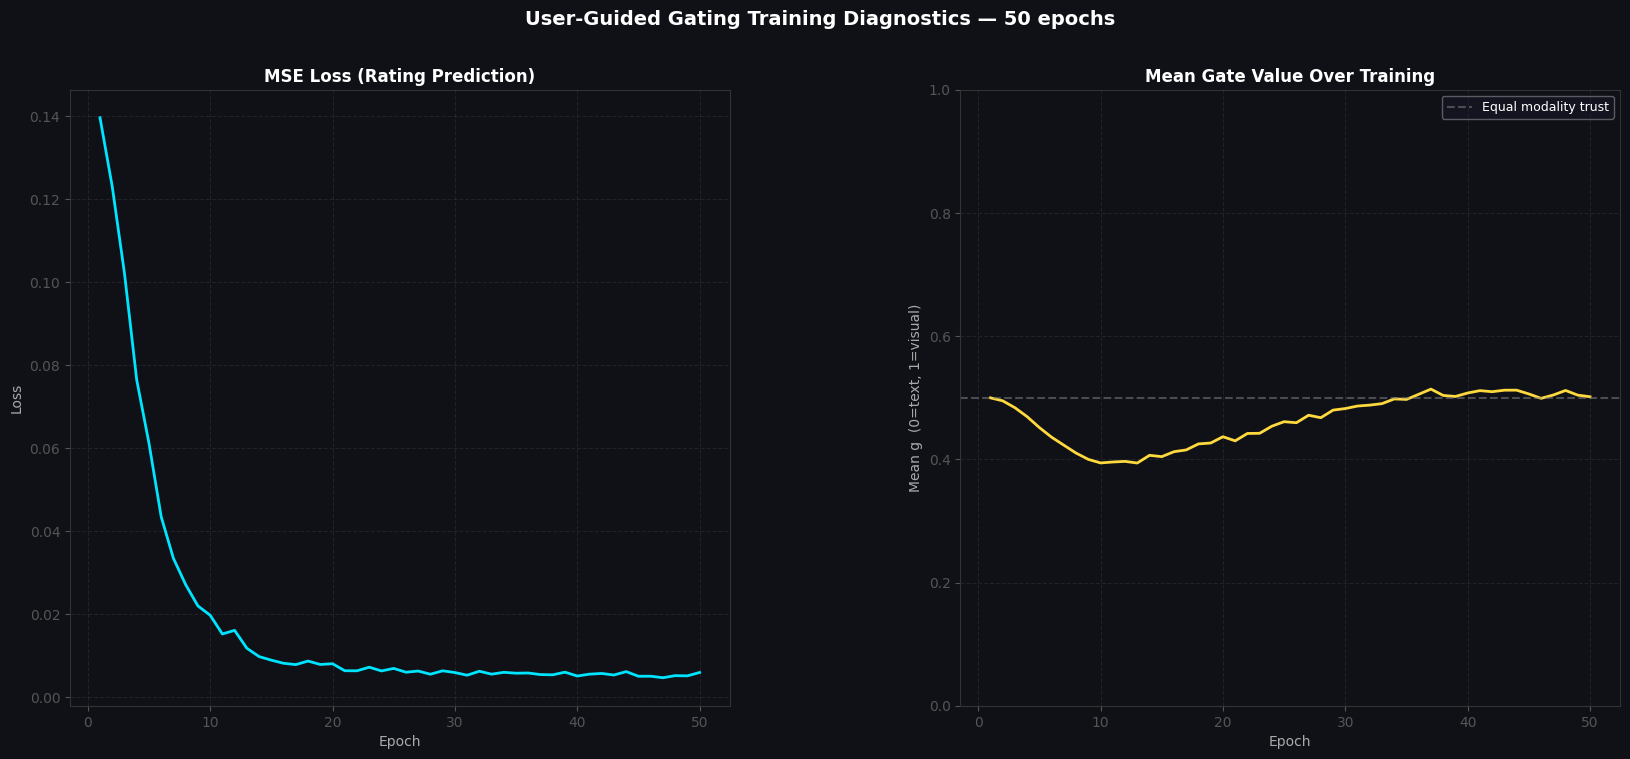

Saved → gating_training_diagnostics.png


In [8]:
epochs_x = list(range(1, EPOCHS + 1))

fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax_style = dict(facecolor="#0f1117")

# ── Plot 1: MSE loss ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], **ax_style)
ax1.plot(epochs_x, history["mse_loss"], color="#00e5ff", linewidth=2)
ax1.set_title("MSE Loss (Rating Prediction)", color="white", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch", color="#aaa")
ax1.set_ylabel("Loss", color="#aaa")
ax1.tick_params(colors="#555")
ax1.grid(True, linestyle="--", alpha=0.15, color="#888")
for spine in ax1.spines.values(): spine.set_edgecolor("#333")

# ── Plot 2: Mean gate value ───────────────────────────────────────────────────
# 0.5 = equal trust in both modalities.
# Drifting toward 1.0 = model prefers visual embeddings globally.
# Drifting toward 0.0 = model prefers text embeddings globally.
ax2 = fig.add_subplot(gs[0, 1], **ax_style)
ax2.plot(epochs_x, history["mean_gate"], color="#ffd93d", linewidth=2)
ax2.axhline(0.5, color="#888", linestyle="--", alpha=0.5, label="Equal modality trust")
ax2.set_title("Mean Gate Value Over Training", color="white", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch", color="#aaa")
ax2.set_ylabel("Mean g  (0=text, 1=visual)", color="#aaa")
ax2.set_ylim(0, 1)
ax2.tick_params(colors="#555")
ax2.grid(True, linestyle="--", alpha=0.15, color="#888")
ax2.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4, fontsize=9)
for spine in ax2.spines.values(): spine.set_edgecolor("#333")

fig.suptitle(
    f"User-Guided Gating Training Diagnostics — {EPOCHS} epochs",
    fontsize=14, fontweight="bold", color="white",
)
plt.savefig("gating_training_diagnostics.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → gating_training_diagnostics.png")

## Cell 9 — Inspect What the Gate Learned Per User

For each user, we compute their **average gate value** across all their interactions.  
This tells us whether the model has learned that user prefers visual or text signals.

A value consistently above 0.5 → this user's ratings align better with image quality.  
A value consistently below 0.5 → this user's ratings align better with review text.

Gate value statistics across 37 users:
  Mean   : 0.5018
  Std    : 0.1350
  Min    : 0.2995
  Max    : 0.7159

  Visual-biased users (g > 0.5) : 18  (48.6%)
  Text-biased users   (g ≤ 0.5) : 19  (51.4%)


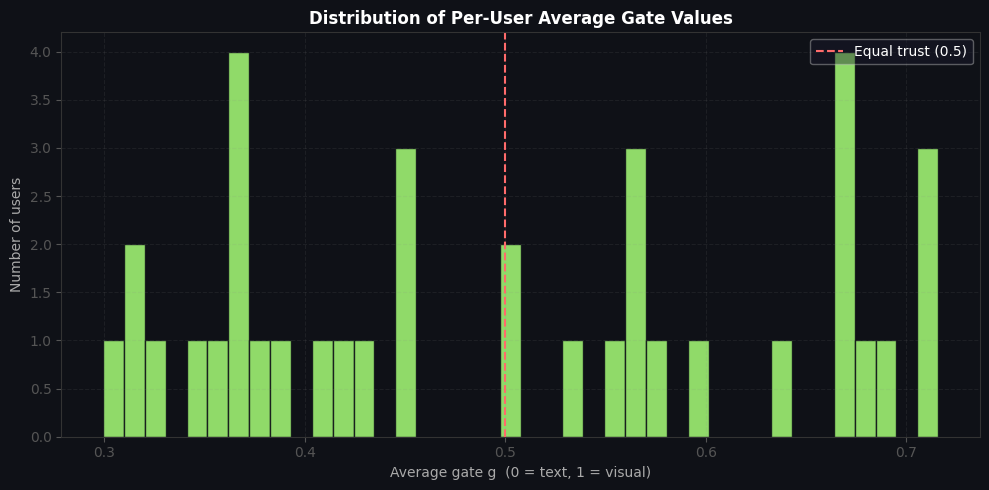

Saved → user_gate_distribution.png


In [9]:
model.eval()

# Accumulate gate values per user
user_gate_sum   = defaultdict(float)
user_gate_count = defaultdict(int)

with torch.no_grad():
    for batch in dataloader:
        z_v      = batch["z_v"].to(DEVICE)
        z_t      = batch["z_t"].to(DEVICE)
        user_idx = batch["user_idx"].to(DEVICE)
        user_ids = batch["user_id"]

        _, _, g, _ = model(z_v, z_t, user_idx)
        g_mean_per_sample = g.mean(dim=1).cpu().numpy()  # average gate across 768 dims

        for i, uid in enumerate(user_ids):
            user_gate_sum[uid]   += g_mean_per_sample[i]
            user_gate_count[uid] += 1

user_avg_gate = {
    uid: user_gate_sum[uid] / user_gate_count[uid]
    for uid in user_gate_sum
}

gate_values = np.array(list(user_avg_gate.values()))

print(f"Gate value statistics across {len(gate_values):,} users:")
print(f"  Mean   : {gate_values.mean():.4f}")
print(f"  Std    : {gate_values.std():.4f}")
print(f"  Min    : {gate_values.min():.4f}")
print(f"  Max    : {gate_values.max():.4f}")
print()
visual_biased = (gate_values > 0.5).sum()
text_biased   = (gate_values <= 0.5).sum()
print(f"  Visual-biased users (g > 0.5) : {visual_biased:,}  ({100*visual_biased/len(gate_values):.1f}%)")
print(f"  Text-biased users   (g ≤ 0.5) : {text_biased:,}  ({100*text_biased/len(gate_values):.1f}%)")

# Plot distribution of per-user gate values
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")
ax.hist(gate_values, bins=40, color="#a8ff78", edgecolor="#0f1117", alpha=0.85)
ax.axvline(0.5, color="#ff6b6b", linestyle="--", linewidth=1.5, label="Equal trust (0.5)")
ax.set_title("Distribution of Per-User Average Gate Values", color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("Average gate g  (0 = text, 1 = visual)", color="#aaa")
ax.set_ylabel("Number of users", color="#aaa")
ax.tick_params(colors="#555")
ax.grid(True, linestyle="--", alpha=0.12, color="#888")
ax.legend(labelcolor="white", facecolor="#1a1a2e", framealpha=0.4)
for spine in ax.spines.values(): spine.set_edgecolor("#333")
plt.tight_layout()
plt.savefig("user_gate_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → user_gate_distribution.png")

## Cell 10 — Visualise User Embeddings via PCA

Project the 64-dim user embeddings into 2D.  
Points are coloured by each user's average rating — this tells us whether  
the embedding space has captured rating tendency as a dimension.

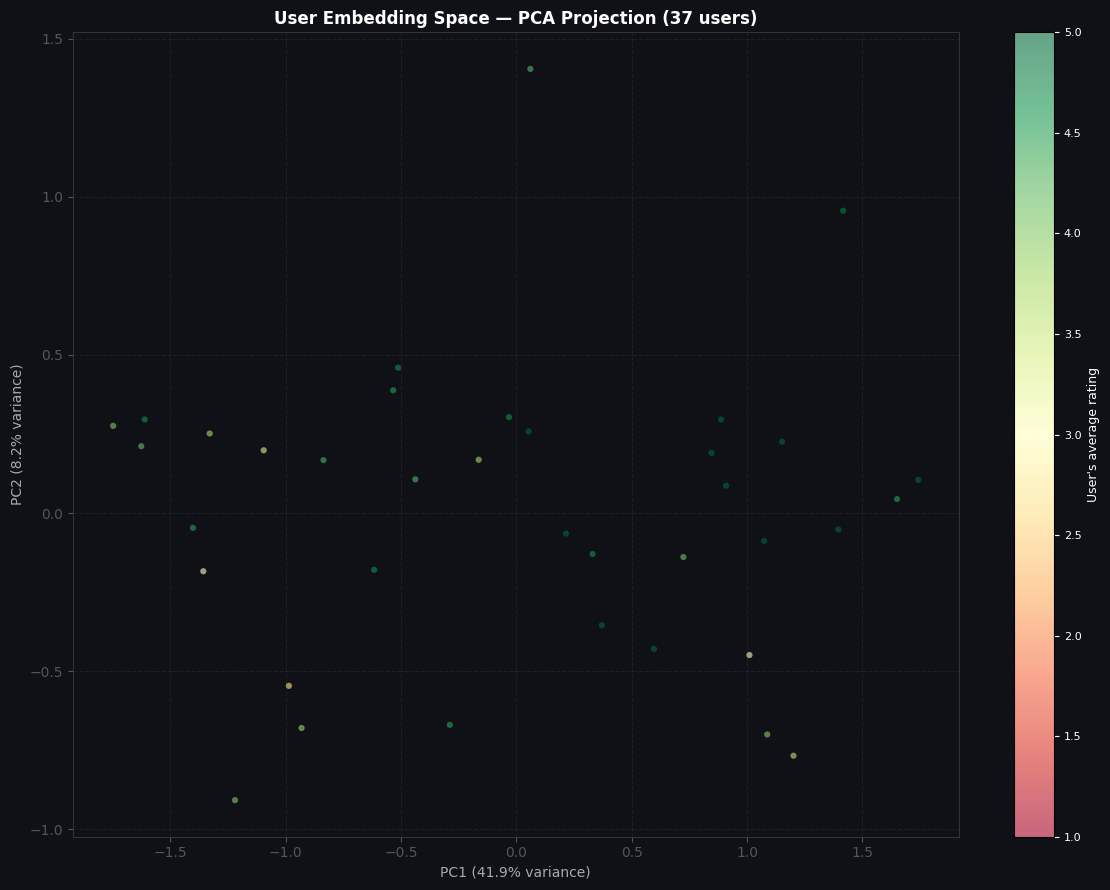

Saved → user_embedding_pca.png

What to look for:
  ✓ Red dots (low avg rating) and green dots (high avg rating) cluster separately
    → embedding captured rating tendency
  ✓ Spread out points → embeddings are diverse, not collapsed to a single point
  If all points are in one blob → more training epochs needed


In [10]:
# Collect all user embeddings and their average ratings
all_user_embs   = model.user_embedding.weight.detach().cpu().numpy()  # (num_users, USER_DIM)

# Compute average rating per user from the dataset
user_rating_sum   = defaultdict(float)
user_rating_count = defaultdict(int)

for rec in dataset.records:
    uid = rec["user_id"]
    user_rating_sum[uid]   += rec["raw_rating"]
    user_rating_count[uid] += 1

user_avg_ratings = np.array([
    user_rating_sum[uid] / user_rating_count[uid]
    for uid in unique_users
])

# PCA projection
pca       = PCA(n_components=2)
embs_2d   = pca.fit_transform(all_user_embs)   # (num_users, 2)
var_ratio = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

sc = ax.scatter(
    embs_2d[:, 0], embs_2d[:, 1],
    c=user_avg_ratings, cmap="RdYlGn",
    vmin=1, vmax=5,
    s=20, alpha=0.6, edgecolors="none",
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("User's average rating", color="white", fontsize=9)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=8)

ax.set_title(
    f"User Embedding Space — PCA Projection ({num_users:,} users)",
    color="white", fontsize=12, fontweight="bold"
)
ax.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}% variance)", color="#aaa")
ax.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}% variance)", color="#aaa")
ax.tick_params(colors="#555")
ax.grid(True, linestyle="--", alpha=0.12, color="#888")
for spine in ax.spines.values(): spine.set_edgecolor("#333")

plt.tight_layout()
plt.savefig("user_embedding_pca.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → user_embedding_pca.png")
print()
print("What to look for:")
print("  ✓ Red dots (low avg rating) and green dots (high avg rating) cluster separately")
print("    → embedding captured rating tendency")
print("  ✓ Spread out points → embeddings are diverse, not collapsed to a single point")
print("  If all points are in one blob → more training epochs needed")

## Cell 11 — Save User Embeddings to JSON

Saves the final trained embedding for every user.  
Format: `{"user_id": [float, float, ...], ...}`  
Also saves the `user2idx` mapping so the file is self-contained.

In [11]:
# Extract final trained embeddings from the model
trained_weights = model.user_embedding.weight.detach().cpu().numpy()  # (num_users, USER_DIM)

user_embeddings_out = {
    uid: trained_weights[user2idx[uid]].tolist()
    for uid in unique_users
}

output = {
    "metadata": {
        "num_users"  : num_users,
        "user_dim"   : USER_DIM,
        "epochs"     : EPOCHS,
        "description": "Trained user embeddings from User-Guided Gating step",
    },
    "embeddings": user_embeddings_out,
}

with open(USER_EMBEDDINGS_OUT, "w") as f:
    json.dump(output, f)

print(f"Saved {num_users:,} user embeddings (dim={USER_DIM}) → {USER_EMBEDDINGS_OUT}")
print()
print("To load and use later:")
print("  with open('user_embeddings.json') as f:")
print("      saved = json.load(f)")
print("  vec = saved['embeddings']['USER_ID_STRING']   # list of 64 floats")

Saved 37 user embeddings (dim=64) → user_embeddings.json

To load and use later:
  with open('user_embeddings.json') as f:
      saved = json.load(f)
  vec = saved['embeddings']['USER_ID_STRING']   # list of 64 floats


## Cell 12 — Save Gated Interactions

Writes `interactions_gated.jsonl` — one record per interaction, augmented with:
- `Z_ui` — the unified gated representation (768-dim)
- `g_mean` — scalar summary of the gate (how visual vs text this prediction was)
- `y_hat` — the model's predicted rating

### Output schema
```json
{
  "user_id"   : str,
  "asin"      : str,
  "rating"    : float,
  "Z_ui"      : list[float],   // len=768, unified gated representation
  "g_mean"    : float,         // avg gate value (0=text, 1=visual)
  "y_hat"     : float          // model's predicted rating (1–5 scale)
}
```

In [12]:
print(f"Generating gated representations and saving to {OUTPUT_PATH}...")

model.eval()
written = 0

with open(OUTPUT_PATH, "w") as out_f:
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Saving"):
            z_v      = batch["z_v"].to(DEVICE)
            z_t      = batch["z_t"].to(DEVICE)
            user_idx = batch["user_idx"].to(DEVICE)

            y_hat, Z_ui, g, _ = model(z_v, z_t, user_idx)

            Z_ui_np  = Z_ui.cpu().numpy()
            g_np     = g.mean(dim=1).cpu().numpy()    # scalar per sample
            y_hat_np = y_hat.cpu().numpy()

            B = Z_ui_np.shape[0]
            for i in range(B):
                record = {
                    "user_id"   : batch["user_id"][i],
                    "asin"      : batch["asin"][i],
                    "rating"    : batch["raw_rating"][i],
                    "Z_ui"      : Z_ui_np[i].tolist(),
                    "g_mean"    : float(g_np[i]),
                    # Convert predicted rating from [0,1] back to [1,5] scale
                    "y_hat"     : float(y_hat_np[i]) * 4.0 + 1.0,
                }
                out_f.write(json.dumps(record) + "\n")
                written += 1

print(f"\nSaved {written:,} records → {OUTPUT_PATH}")
print(f"Saved {num_users:,} user embeddings → {USER_EMBEDDINGS_OUT}")
print()
print("Next step → Final evaluation / downstream recommendation task")
print("  Input : interactions_gated.jsonl")
print("  Z_ui  : unified representation ready for ranking / retrieval")

Generating gated representations and saving to interactions_gated.jsonl...


Saving: 100%|██████████| 6/6 [00:00<00:00, 57.46it/s]


Saved 166 records → interactions_gated.jsonl
Saved 37 user embeddings → user_embeddings.json

Next step → Final evaluation / downstream recommendation task
  Input : interactions_gated.jsonl
  Z_ui  : unified representation ready for ranking / retrieval
